# Unit 4 — Notebook 4: CI/CD Pipelines for ML Model Delivery

**What you will learn:**
1. What CI/CD means for ML and how it differs from software-only CI/CD
2. The stages of an ML pipeline: test, train, validate, build, deploy, smoke test
3. How to write a GitHub Actions workflow for ML deployment
4. How to build a model validation gate and a smoke test that CI/CD can call

**Everything here runs locally.** GitHub Actions runs on GitHub's servers — the YAML we write here is what gets committed to `.github/workflows/`. The validation and smoke test scripts run directly in this notebook via `subprocess`.


---
## Section 1 — What CI/CD Means for ML

**Continuous Integration (CI):** Every time a developer pushes code, an automated system runs tests. If tests fail, the push is blocked. This catches bugs before they reach users.

**Continuous Delivery (CD):** When CI passes, the system automatically deploys the change to production (or stages it for a human approval step).

**ML adds a third gate — model validation:** Before deploying, you must verify that the trained model meets accuracy, latency, and safety thresholds. A model that passes unit tests but has 60% accuracy should not go to production.

### Why this matters

Without CI/CD, deploying a new model version requires a developer to:
1. Train the model locally
2. Manually evaluate it
3. Manually build and push a Docker image
4. Manually update the K8s deployment
5. Manually run curl commands to check it works

Each manual step is a place where humans make mistakes and skip steps. CI/CD makes the process fast, repeatable, and auditable.


---
## Section 2 — The ML CI/CD Pipeline Stages

The diagram below shows the full pipeline triggered on every push to `main`.


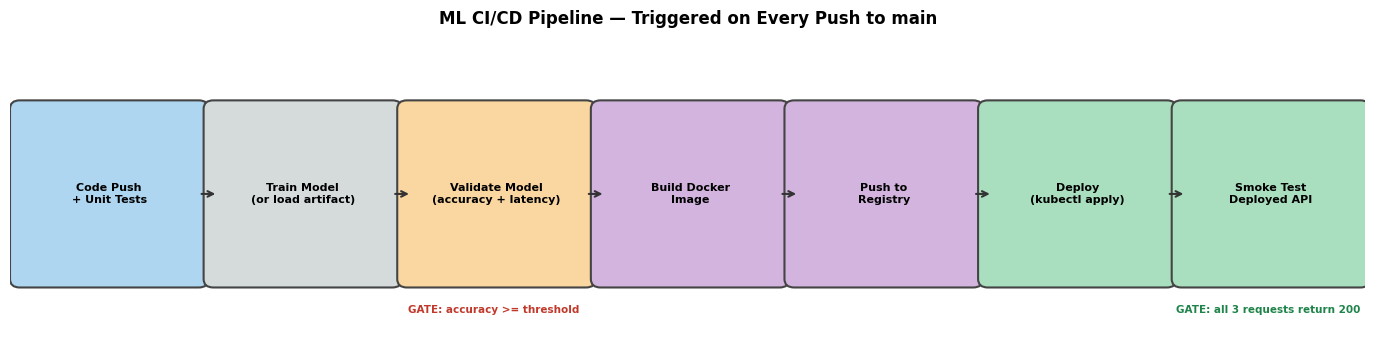

In [1]:
# WHAT: draw the 7-stage ML CI/CD pipeline with its two hard gates.
# WHY: this diagram is the lesson's contract — each stage becomes a real file
# or command below; the red/green gates are where bad models get stopped.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3.5)
ax.axis('off')

# One box per stage, in execution order; arrows show the dependency chain.
stages = [
    (0.1, 'Code Push\n+ Unit Tests', '#AED6F1'),
    (2.1, 'Train Model\n(or load artifact)', '#D5DBDB'),
    (4.1, 'Validate Model\n(accuracy + latency)', '#FAD7A0'),
    (6.1, 'Build Docker\nImage', '#D2B4DE'),
    (8.1, 'Push to\nRegistry', '#D2B4DE'),
    (10.1, 'Deploy\n(kubectl apply)', '#A9DFBF'),
    (12.1, 'Smoke Test\nDeployed API', '#A9DFBF'),
]

for i, (x, label, color) in enumerate(stages):
    rect = mpatches.FancyBboxPatch((x, 0.6), 1.85, 2.0,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#444', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.925, 1.6, label, ha='center', va='center', fontsize=8, fontweight='bold')
    if i < len(stages) - 1:
        ax.annotate('', xy=(x + 2.05, 1.6), xytext=(x + 1.85, 1.6),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

# Gate markers
ax.text(5.0, 0.2, 'GATE: accuracy >= threshold', ha='center', fontsize=7.5,
        color='#C0392B', fontweight='bold')
ax.text(13.0, 0.2, 'GATE: all 3 requests return 200', ha='center', fontsize=7.5,
        color='#1E8449', fontweight='bold')

ax.set_title('ML CI/CD Pipeline — Triggered on Every Push to main', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — GitHub Actions Workflow

GitHub Actions reads YAML files from `.github/workflows/`. When you push to `main`, GitHub runs each `job` in the workflow. Jobs can depend on each other — `train-and-validate` only runs if `test` passes.


In [2]:
import os
os.makedirs('.github/workflows', exist_ok=True)
print('Created .github/workflows/ directory')


Created .github/workflows/ directory


In [3]:
%%writefile .github/workflows/ml-deploy.yml
# WHAT: write the GitHub Actions workflow — four jobs chained by `needs:`.
# WHY: the chain IS the safety mechanism: tests gate training, validation gates
# the image build, and only a pushed image can be deployed.
name: ML Model CI/CD

# Trigger: every push to the main branch
on:
  push:
    branches: [main]

env:
  IMAGE_NAME: iris-api
  REGISTRY: ghcr.io/${{ github.repository_owner }}

jobs:
  # ── Job 1: Unit Tests ──────────────────────────────────────────────────
  test:
    name: Run unit tests
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Set up Python 3.10
        uses: actions/setup-python@v4
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: |
          pip install -r app/requirements.txt
          pip install pytest

      - name: Run tests
        run: pytest tests/ -v
        # If any test fails, this job fails and downstream jobs are skipped.

  # ── Job 2: Train and Validate ──────────────────────────────────────────
  train-and-validate:
    name: Train model and run validation gate
    needs: test          # Only runs if 'test' job passes
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Set up Python 3.10
        uses: actions/setup-python@v4
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: pip install -r app/requirements.txt

      - name: Train model
        run: python app/model_train.py
        # Saves model artifact to app/model/iris_rf.joblib

      - name: Validate model
        run: python validate_model.py
        # Exits with code 1 if accuracy < 0.90 or p95 latency > 100ms
        # GitHub Actions treats non-zero exit as a failure — blocks deploy

      - name: Upload model artifact
        uses: actions/upload-artifact@v3
        with:
          name: trained-model
          path: app/model/
          # Share the trained model with the build job below

  # ── Job 3: Build and Push Docker Image ────────────────────────────────
  build-and-push:
    name: Build Docker image and push to registry
    needs: train-and-validate
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Download model artifact
        uses: actions/download-artifact@v3
        with:
          name: trained-model
          path: app/model/

      - name: Log in to registry
        run: echo "${{ secrets.GITHUB_TOKEN }}" | docker login ghcr.io -u ${{ github.actor }} --password-stdin

      - name: Build and tag image
        run: |
          docker build -t $REGISTRY/$IMAGE_NAME:${{ github.sha }} app/
          docker tag $REGISTRY/$IMAGE_NAME:${{ github.sha }} $REGISTRY/$IMAGE_NAME:latest

      - name: Push image
        run: |
          docker push $REGISTRY/$IMAGE_NAME:${{ github.sha }}
          docker push $REGISTRY/$IMAGE_NAME:latest

  # ── Job 4: Deploy to Kubernetes ───────────────────────────────────────
  deploy:
    name: Deploy to Kubernetes
    needs: build-and-push
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Configure kubectl
        run: echo "${{ secrets.KUBECONFIG }}" > /tmp/kubeconfig
        # KUBECONFIG is a secret stored in GitHub repo settings

      - name: Update image tag in deployment
        run: |
          KUBECONFIG=/tmp/kubeconfig kubectl set image \
            deployment/iris-api \
            iris-api=$REGISTRY/$IMAGE_NAME:${{ github.sha }}

      - name: Wait for rollout
        run: |
          KUBECONFIG=/tmp/kubeconfig kubectl rollout status \
            deployment/iris-api --timeout=120s

      - name: Run smoke test
        run: |
          pip install requests
          python smoke_test.py
          # Sends 3 test requests; fails if any returns non-200

Overwriting .github/workflows/ml-deploy.yml


### Key points in the workflow

- **`needs:`** creates a dependency chain. If `test` fails, `train-and-validate`, `build-and-push`, and `deploy` never run. Nothing broken reaches production.
- **Secrets** (`GITHUB_TOKEN`, `KUBECONFIG`) are stored in GitHub's encrypted secret store — never hardcoded in YAML.
- **Image tagged with `github.sha`** means every image is uniquely traceable to the commit that produced it. Rollback = apply the previous sha's image tag.
- The **smoke test** runs against the live deployed endpoint — it is the final gate before the pipeline is considered green.
- The **`test` job** runs `pytest tests/`. That `tests/` directory is real code you commit to the repo — we create a minimal version of it in the next cell so the job has something to run.


### Section 4b — The unit tests the workflow runs

The workflow's first job runs `pytest tests/`. Those tests live in a `tests/`
directory you commit alongside your code. Below we create a minimal version so
the `test` job actually has something to run (and passes). These tests check the
*prediction logic* — they train a small model in-memory and assert it behaves
sanely, with no dependency on a saved artifact or a running server.


In [4]:
# WHAT: write three pytest unit tests for the model into tests/test_model.py.
# WHY: these are the pipeline's first gate — cheap, fast checks (shape, valid
# classes, sane accuracy) that catch broken code before any expensive step.
import os

os.makedirs('tests', exist_ok=True)

test_code = '''import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def _train():
    iris = load_iris()
    X_tr, X_te, y_tr, y_te = train_test_split(
        iris.data, iris.target, test_size=0.2, random_state=42
    )
    clf = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_tr, y_tr)
    return clf, X_te, y_te


def test_predict_returns_one_label_per_row():
    clf, X_te, _ = _train()
    preds = clf.predict(X_te)
    assert len(preds) == len(X_te)


def test_predictions_are_valid_classes():
    clf, X_te, _ = _train()
    assert set(clf.predict(X_te)).issubset({0, 1, 2})


def test_accuracy_is_reasonable():
    clf, X_te, y_te = _train()
    assert accuracy_score(y_te, clf.predict(X_te)) > 0.8
'''

with open('tests/test_model.py', 'w') as f:
    f.write(test_code)

print("Wrote tests/test_model.py with 3 unit tests")

Wrote tests/test_model.py with 3 unit tests


In [5]:
# WHAT: run pytest locally, exactly as the CI `test` job would.
# WHY: the exit code is the interface between steps — CI systems know nothing
# about Python, they only read 0 (continue) or non-zero (stop).
import subprocess, sys

# This is exactly what the workflow's `test` job runs: pytest tests/ -v
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v"],
    capture_output=True, text=True
)
print(result.stdout[-2000:])
if result.stderr:
    print("STDERR:", result.stderr[-500:])
print(f"Exit code: {result.returncode}  "
      f"({'tests passed -> CI continues' if result.returncode == 0 else 'tests failed -> CI stops'})")

============================= test session starts ==============================
platform darwin -- Python 3.14.3, pytest-9.1.1, pluggy-1.6.0 -- /Users/abdullah/Downloads/AI Diploma/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/abdullah/Downloads/AI Diploma/Course 11/unit4-containers-orchestration/examples
plugins: anyio-4.13.0
collecting ... collected 3 items

tests/test_model.py::test_predict_returns_one_label_per_row PASSED       [ 33%]
tests/test_model.py::test_predictions_are_valid_classes PASSED           [ 66%]
tests/test_model.py::test_accuracy_is_reasonable PASSED                  [100%]

============================== 3 passed in 0.76s ===============================

Exit code: 0  (tests passed -> CI continues)


---
## Section 4 — Model Validation Gate

The validation script is called by CI/CD. It exits with code 0 (success) or code 1 (failure). GitHub Actions treats a non-zero exit code as a job failure, which blocks the next job from running.

This is the script we write and commit to the repo — CI calls it exactly the same way you would run it locally.


In [6]:
%%writefile validate_model.py
# WHAT: write validate_model.py — the accuracy + latency gate as a standalone script.
# WHY: a gate must be a script, not a notebook: CI runs it headless and its
# sys.exit code decides whether the Docker build ever happens.
"""Model validation gate for CI/CD.

Checks:
  1. Test-set accuracy >= ACCURACY_THRESHOLD
  2. p95 inference latency < LATENCY_P95_MS

Exit codes:
  0 = all checks pass  (CI proceeds to build)
  1 = at least one check failed  (CI blocks deployment)
"""
import sys
import time
import numpy as np
import joblib
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

ACCURACY_THRESHOLD = 0.90   # 90% minimum test accuracy
LATENCY_P95_MS     = 100.0  # 100ms maximum p95 latency
N_LATENCY_SAMPLES  = 200    # number of predictions for latency measurement
MODEL_PATH         = "app/model/iris_rf.joblib"


# Gate 1: holdout accuracy against the fixed threshold.
def check_accuracy(model, X_test, y_test):
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    status = "PASS" if acc >= ACCURACY_THRESHOLD else "FAIL"
    print(f"[{status}] Accuracy: {acc:.4f} (threshold: {ACCURACY_THRESHOLD})")
    return acc >= ACCURACY_THRESHOLD


# Gate 2: p95 of single-sample predictions against the latency budget.
def check_latency(model, X_test):
    samples = X_test[:N_LATENCY_SAMPLES]
    latencies = []
    for row in samples:
        t0 = time.perf_counter()
        model.predict([row])
        latencies.append((time.perf_counter() - t0) * 1000)  # ms
    p95 = float(np.percentile(latencies, 95))
    status = "PASS" if p95 < LATENCY_P95_MS else "FAIL"
    print(f"[{status}] p95 latency: {p95:.2f}ms (threshold: {LATENCY_P95_MS}ms)")
    return p95 < LATENCY_P95_MS


# Load artifact, run both gates, and exit 0 (pass) or 1 (block deploy).
def main():
    print("=== Model Validation Gate ===")

    # Load model
    try:
        model = joblib.load(MODEL_PATH)
        print(f"Loaded model from {MODEL_PATH}")
    except FileNotFoundError:
        print(f"[FAIL] Model not found at {MODEL_PATH}")
        sys.exit(1)

    # Load test data (same split used during training)
    iris = load_iris()
    X, y = iris.data, iris.target
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Run checks
    accuracy_ok = check_accuracy(model, X_test, y_test)
    latency_ok  = check_latency(model, X_test)

    if accuracy_ok and latency_ok:
        print("\nAll checks passed. Model is approved for deployment.")
        sys.exit(0)
    else:
        print("\nOne or more checks failed. Deployment blocked.")
        sys.exit(1)


if __name__ == "__main__":
    main()

Overwriting validate_model.py


In [7]:
# WHAT: train and save the model the validation gate expects at app/model/.
# WHY: in the real pipeline the training JOB produces this artifact; here we
# create it so the next cell can run the gate against something real.
# First, make sure we have a trained model
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
import os

os.makedirs('app/model', exist_ok=True)
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
joblib.dump(clf, 'app/model/iris_rf.joblib')
print("Model trained and saved to app/model/iris_rf.joblib")

Model trained and saved to app/model/iris_rf.joblib


In [8]:
# WHAT: run validate_model.py as a subprocess, exactly as the CI job would.
# WHY: what matters is the printed report AND the exit code — CI reads only the code.
import subprocess, sys

# Run the validation gate exactly as CI/CD would.
# Use sys.executable (the interpreter running this notebook) so it works
# whether your system's command is `python` or `python3`.
result = subprocess.run(
    [sys.executable, "validate_model.py"],
    capture_output=True, text=True
)
# The gate's report plus its exit code — the only two things CI sees.
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr)
print(f"Exit code: {result.returncode}")
print("(In CI/CD, exit code 0 = proceed to build; exit code 1 = block pipeline)")

=== Model Validation Gate ===
Loaded model from app/model/iris_rf.joblib
[PASS] Accuracy: 1.0000 (threshold: 0.9)
[PASS] p95 latency: 1.91ms (threshold: 100.0ms)

All checks passed. Model is approved for deployment.

Exit code: 0
(In CI/CD, exit code 0 = proceed to build; exit code 1 = block pipeline)


### Testing the failure path

A quality gate is only trustworthy if we have SEEN it block. Let's feed it a
deliberately bad deploy candidate — the same model class trained on just 5 rows —
and verify the gate actually stops it.

In [9]:
# WHAT: demonstrate the gate FAILING — validate a model trained on only 5 rows.
# WHY: a gate that never fails is decoration; seeing the FAIL path proves the
# pipeline would really stop a bad model before Docker build and deploy.
import subprocess

# Monkey-patch the threshold by passing an env variable override
# We'll just directly test the logic in Python here

import sys
import numpy as np
import joblib
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# A deliberately BAD deploy candidate: trained on only 5 rows
bad_model = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_train[:5], y_train[:5])
acc = accuracy_score(y_test, bad_model.predict(X_test))

THRESHOLD = 0.95   # same gate the real pipeline uses
accuracy_ok = acc >= THRESHOLD
status = "PASS" if accuracy_ok else "FAIL"
print(f"[{status}] Accuracy: {acc:.4f} (threshold: {THRESHOLD})")
print()
if not accuracy_ok:
    print("Validation FAILED. In CI/CD, the pipeline would stop here.")
    print("The Docker build and kubectl apply would NOT run.")
    print("The broken model never reaches production.")

[FAIL] Accuracy: 0.5333 (threshold: 0.95)

Validation FAILED. In CI/CD, the pipeline would stop here.
The Docker build and kubectl apply would NOT run.
The broken model never reaches production.


---
## Section 5 — Smoke Test

A smoke test is a quick sanity check run against the *deployed* endpoint right after deployment. It does not test every edge case — it just confirms the service is alive and returning sensible responses. If the smoke test fails, the CI/CD pipeline can automatically trigger a rollback.

In this notebook, the endpoint won't be running, so we'll also show a mock version that verifies the logic works.


In [10]:
%%writefile smoke_test.py
# WHAT: write smoke_test.py — post-deployment checks against the LIVE endpoint.
# WHY: validation tested the model file; the smoke test checks the deployed
# SYSTEM — network, container, server — with three known-answer requests.
"""Smoke test for the deployed iris-api endpoint.

Runs after deployment in CI/CD.
Sends 3 known-good requests and asserts 200 OK responses.

Usage:
    python smoke_test.py [--url http://your-endpoint]

Exit codes:
    0 = all checks pass
    1 = at least one check failed
"""
import sys
import argparse

try:
    import requests
except ImportError:
    print("[SKIP] requests library not installed. Run: pip install requests")
    sys.exit(0)

# The endpoint URL is a flag so the same script tests staging or production.
parser = argparse.ArgumentParser()
parser.add_argument("--url", default="http://localhost:8000",
                    help="Base URL of the deployed API")
args = parser.parse_args()

BASE_URL = args.url

# Three representative Iris samples (one per class)
# Known-answer requests: one flower per class, with the expected label.
TEST_CASES = [
    {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2},  # setosa
    {"sepal_length": 6.4, "sepal_width": 3.2, "petal_length": 4.5, "petal_width": 1.5},  # versicolor
    {"sepal_length": 7.7, "sepal_width": 3.0, "petal_length": 6.1, "petal_width": 2.3},  # virginica
]

EXPECTED_PREDICTIONS = ["setosa", "versicolor", "virginica"]

print(f"=== Smoke Test against {BASE_URL} ===")

# Check health endpoint first
try:
    r = requests.get(f"{BASE_URL}/health", timeout=5)
    r.raise_for_status()
    print(f"[PASS] /health returned: {r.json()}")
except Exception as e:
    print(f"[FAIL] /health check failed: {e}")
    sys.exit(1)

# Check predict endpoint with test cases
all_passed = True
for i, (payload, expected) in enumerate(zip(TEST_CASES, EXPECTED_PREDICTIONS)):
    try:
        r = requests.post(f"{BASE_URL}/predict", json=payload, timeout=5)
        assert r.status_code == 200, f"Status {r.status_code}"
        body = r.json()
        assert "prediction" in body, "Missing 'prediction' key"
        assert body["prediction"] == expected, (
            f"Expected {expected}, got {body['prediction']}"
        )
        print(f"[PASS] Case {i+1}: {payload} -> {body['prediction']} "
              f"(confidence={body.get('confidence', '?')})")
    except Exception as e:
        print(f"[FAIL] Case {i+1}: {e}")
        all_passed = False

if all_passed:
    print("\nAll smoke tests passed. Deployment is healthy.")
    sys.exit(0)
else:
    print("\nSmoke test failed. CI/CD should trigger rollback.")
    sys.exit(1)

Overwriting smoke_test.py


In [11]:
# WHAT: run smoke_test.py against localhost — expected to FAIL here (no server).
# WHY: seeing the failure output teaches what CI would report on a dead deploy.
import subprocess, sys

# Run the smoke test — it will fail gracefully because no server is running.
# sys.executable keeps this portable across `python` / `python3` setups.
result = subprocess.run(
    [sys.executable, "smoke_test.py", "--url", "http://localhost:8000"],
    capture_output=True, text=True
)
# Expected to fail here (no server running) — the point is reading its report.
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[:500])
print(f"Exit code: {result.returncode}")
print()
print("When the server IS running (after docker run or kubectl deploy),")
print("the same command returns exit code 0 and all tests pass.")

=== Smoke Test against http://localhost:8000 ===
[FAIL] /health check failed: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /health (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 61] Connection refused"))

Exit code: 1

When the server IS running (after docker run or kubectl deploy),
the same command returns exit code 0 and all tests pass.


### Simulating a successful smoke test

Since no server is running here, we simulate the test logic directly to verify it works.


In [12]:
# Simulate what smoke_test.py does — call the model directly instead of HTTP
import joblib
import numpy as np

# Same known-answer cases, but calling the model directly — no HTTP layer.
model = joblib.load('app/model/iris_rf.joblib')
CLASSES = ["setosa", "versicolor", "virginica"]

TEST_CASES = [
    ([5.1, 3.5, 1.4, 0.2], "setosa"),
    ([6.4, 3.2, 4.5, 1.5], "versicolor"),
    ([7.7, 3.0, 6.1, 2.3], "virginica"),
]

# Same three cases as smoke_test.py, minus HTTP — isolates the model logic.
print("=== Simulated Smoke Test (direct model calls, no HTTP) ===")
all_passed = True
for i, (features, expected) in enumerate(TEST_CASES):
    pred = CLASSES[model.predict([features])[0]]
    conf = model.predict_proba([features])[0].max()
    ok = pred == expected
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] Case {i+1}: features={features}")
    print(f"         expected={expected}, got={pred}, confidence={conf:.3f}")
    if not ok:
        all_passed = False

print()
if all_passed:
    print("All cases passed. In CI/CD this would return exit code 0.")
    print("Pipeline proceeds — deployment is confirmed healthy.")
else:
    print("Some cases failed. In CI/CD this would return exit code 1.")
    print("CI/CD would trigger: kubectl rollout undo deployment/iris-api")

=== Simulated Smoke Test (direct model calls, no HTTP) ===
[PASS] Case 1: features=[5.1, 3.5, 1.4, 0.2]
         expected=setosa, got=setosa, confidence=1.000
[PASS] Case 2: features=[6.4, 3.2, 4.5, 1.5]
         expected=versicolor, got=versicolor, confidence=1.000
[PASS] Case 3: features=[7.7, 3.0, 6.1, 2.3]
         expected=virginica, got=virginica, confidence=1.000

All cases passed. In CI/CD this would return exit code 0.
Pipeline proceeds — deployment is confirmed healthy.


---
## Summary

A CI/CD pipeline for ML automates the full path from code change to running service:

1. **Unit tests** catch code bugs before any model work begins
2. **Model validation gate** (`validate_model.py`) enforces quality thresholds — a model that passes tests but has poor accuracy never ships
3. **Docker build + push** packages the validated model into a versioned, immutable artifact
4. **`kubectl apply`** updates the running deployment using a rolling strategy (no downtime)
5. **Smoke test** (`smoke_test.py`) confirms the live endpoint is healthy after deployment; CI triggers rollback if it fails

The same scripts you run locally are the ones CI/CD calls. There is no magic — just automated execution of the same workflow.


---
## Self-Check Questions

1. **What is the difference between a test gate and a deployment gate?**
   *(Hint: one runs on code; the other runs on the trained model or the live service.)*

2. **Why would you want to run `validate_model.py` in CI rather than manually before each deployment?**
   *(Hint: think about what happens when the same team ships 20 model updates per month.)*

3. **What is a smoke test and when does it run in the pipeline?**
   *(Hint: is it before or after deployment? What does it test?)*


## 📚 References

1. Shahin, M., Ali Babar, M., & Zhu, L. (2017). *Continuous Integration, Delivery and Deployment: A Systematic Review on Approaches, Tools, Challenges and Practices*. IEEE Access. <https://arxiv.org/abs/1703.07019>
2. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
